In [1]:
using Oceananigans
using NCDatasets
using Printf
using CairoMakie
using Oceananigans.Fields
using Oceananigans.AbstractOperations: volume
using NaNStatistics

Precompiling Oceananigans
  ✓ CUDA_Runtime_jll
  ✓ CUDA
  ✓ ArrayInterface → ArrayInterfaceCUDAExt
  ✓ StridedViews → StridedViewsCUDAExt
  ✓ CUDA → SpecialFunctionsExt
  ✓ MPI → CUDAExt
  ✓ CUDA → ChainRulesCoreExt
  ✓ Oceananigans
  8 dependencies successfully precompiled in 77 seconds. 178 already precompiled.


In [2]:
using TopographicHorizontalConvection
using TopographicHorizontalConvection: HorizontalConvectionSimulation

Precompiling TopographicHorizontalConvection
  ✓ Oceanostics
  ✓ TopographicHorizontalConvection
  2 dependencies successfully precompiled in 16 seconds. 336 already precompiled.


In [3]:
ds_buoy = NCDataset(string("/pub/ikeshwan/code/HorizontalConvection/output/turbulent_h0.6_Ra1.0e8_coldstart_buoyancy.nc"));
ds_vel = NCDataset("/pub/ikeshwan/code/HorizontalConvection/output/turbulent_h0.6_Ra1.0e8_coldstart_velocities.nc");

# Calculation of Fluxes

#### Reversible Vertical Buoyancy Flux:  
$ \phi_z = \int \rho g w dV \rightarrow -\int b w dV $

#### Rate of conversion from internal to potential energy:   
$ \phi_i = -\kappa g A (\bar{\rho}_{top} - \bar{\rho}_{bottom})$

#### Rate of change of background potential due to diapycnal mixing : 
$ \phi_d = \kappa g \int - \frac{dz_*}{d \rho} \left | \nabla \rho \right |^2 dV$

In [4]:
ds_buoy

Dataset: /pub/ikeshwan/code/HorizontalConvection/output/turbulent_h0.6_Ra1.0e8_coldstart_buoyancy.nc
Group: /

Dimensions
   zC = 127
   zF = 128
   xC = 959
   yF = 1
   xF = 960
   yC = 1
   time = 141

Variables
  zC   (127)
    Datatype:    Float64 (Float64)
    Dimensions:  zC
    Attributes:
     units                = m
     long_name            = Locations of the cell centers in the z-direction.

  zF   (128)
    Datatype:    Float64 (Float64)
    Dimensions:  zF
    Attributes:
     units                = m
     long_name            = Locations of the cell faces in the z-direction.

  xC   (959)
    Datatype:    Float64 (Float64)
    Dimensions:  xC
    Attributes:
     units                = m
     long_name            = Locations of the cell centers in the x-direction.

  yF   (1)
    Datatype:    Float64 (Float64)
    Dimensions:  yF
    Attributes:
     units                = m
     long_name            = Locations of the cell faces in the y-direction.

  xF   (960)
    Da

In [6]:
#vertical buoyancy flux

b = ds_buoy["b"][4+1:end-4, :, 4+1:end-4, :];
w = ds_vel["w"][4+1:end-4, :, 5+1:end-4, :];

∫ϕz = ds_buoy["∫ϕz"][4+1:end-4, :, 4+1:end-4, :];

#bw = b .* w;

In [7]:
#define positional arrays

x = ds_buoy["xC"][4+1:end-4]; Nx = length(x);
y = ds_buoy["yC"][:]; Ny =  length(y)
z = ds_buoy["zC"][4+1:end-4]; Nz = length(z);

H = 1.0;
Ly = H/4;
Δy = Ly/Ny;

In [8]:
#integrate bw over volume -- reimann sum
time = ds_buoy["time"][:];

#bw = reshape(bw, Nx, Ny, Nz, length(time));

Δx = reshape(diff(ds_buoy["xF"])[4+1:end-4], Nx,1,1);
Δz = reshape(diff(ds_buoy["zF"])[4+1:end-4], 1, 1, Nz);
ΔA = Δx .* Δy;
ΔV = ΔA .* Δz;

In [9]:
ϕ_z = zeros(size(time,1));
for n in 1:size(time, 1)
    ∫ϕz_t = -1 .* ∫ϕz[:, 1, :, n]
    wet = ∫ϕz_t.!=0
    ∫ϕz_t[.!wet] .= NaN
    ϕ_z[n] = nansum(
        ∫ϕz_t .*
        ΔV, 
        dims=(3)
        )[1,1,1]
end

ϕ_z

141-element Vector{Float64}:
  0.0
 -6.821650327088413e-5
 -6.848746540036408e-5
 -3.665576364980555e-5
 -7.274410209554458e-5
 -7.491749362766541e-5
 -7.202277969460011e-5
 -6.37743467759908e-5
 -5.3288774568536774e-5
 -6.992014144109613e-5
 -5.274910238459716e-5
 -5.6098670898777116e-5
 -4.472610910821834e-5
  ⋮
 -3.0395800018782618e-5
 -3.5259444206911606e-5
 -4.6594972661959474e-5
 -5.0062291687677595e-5
 -1.0628951762460752e-5
 -3.462929129306311e-5
 -3.984538235915337e-5
 -2.676870542301654e-5
 -4.2018011789545905e-5
 -4.433558879187873e-5
 -5.321497272913967e-5
 -8.750363115284774e-6

### Next, let's calculate $\phi_i$

#### Rate of conversion from internal to potential energy:   
$ \phi_i = -\kappa g A (\bar{\rho}_{top} - \bar{\rho}_{bottom}) \rightarrow \kappa A (b_{top} - b_{bottom}) $

In [11]:
b_bottom = TopographicHorizontalConvection.buoyancy_level_avg(ds_buoy, "bottom");
b_top = TopographicHorizontalConvection.buoyancy_level_avg(ds_buoy, "top");
#I cant seem to figure out how to access global attributes from NetCDF files, but upon looking at ds_buoy we know kappa=0.0001
κ = ds_buoy.attrib["κ"];
A = 8

ϕᵢ = (κ * A) .* (b_top .- b_bottom);

In [12]:
ds_buoy.attrib["Ra"]

1.0e8

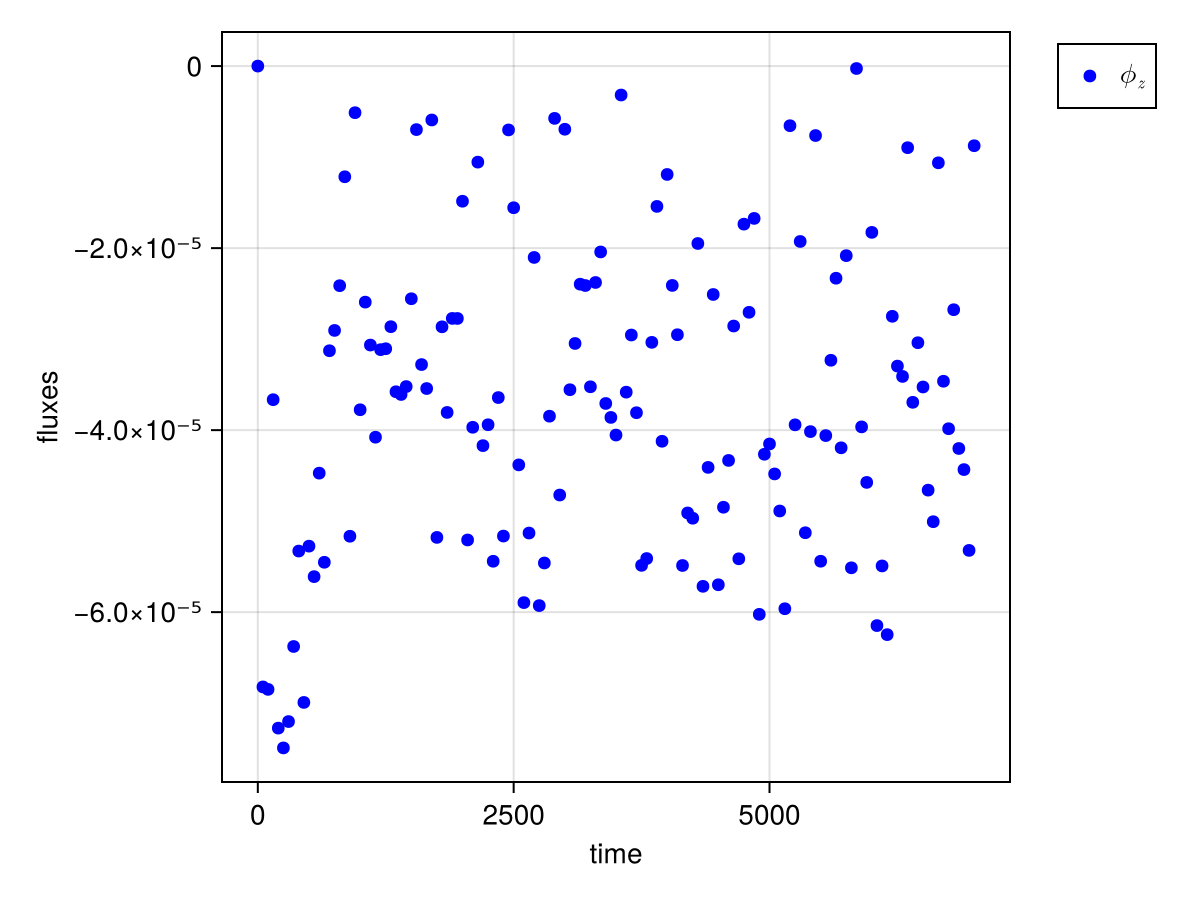

In [13]:
f = Figure()
ax = Axis(f[1,1], xlabel = "time", ylabel= "fluxes")
scatter!(ax, time, ϕ_z, color = "blue", label = L"\phi_z")
#scatter!(ax, time, ϕᵢ, color = "red", label = L"\phi_i")
f[1,2] = axislegend()
f

### Now for $ \phi_d $

#### Rate of change of background potential due to diapycnal mixing : 
$ \phi_d = \kappa g \int - \frac{dz_*}{d \rho} \left | \nabla \rho \right |^2 dV$

#### Method:

first, we need to calculate the flattened 1D arrays for z and b.
to find $z_*$ we need to sort through z and b. Refer to the background_potential_energy.ipynb notebook. 

In [21]:
#so we already have x, z, Δx, and Δz defined above

#since this is a cold start sim, we can use the initial timestep to create wet map
#because buoyancy is not initialized as zero everywhere! cool!
b = ds_buoy["b"][4+1:end-4, 1, 4+1:end-4, 1];
wet = b.!=0.

b[.!wet] .= NaN; #wherever the buoyancy is zero == hills == land == NaN

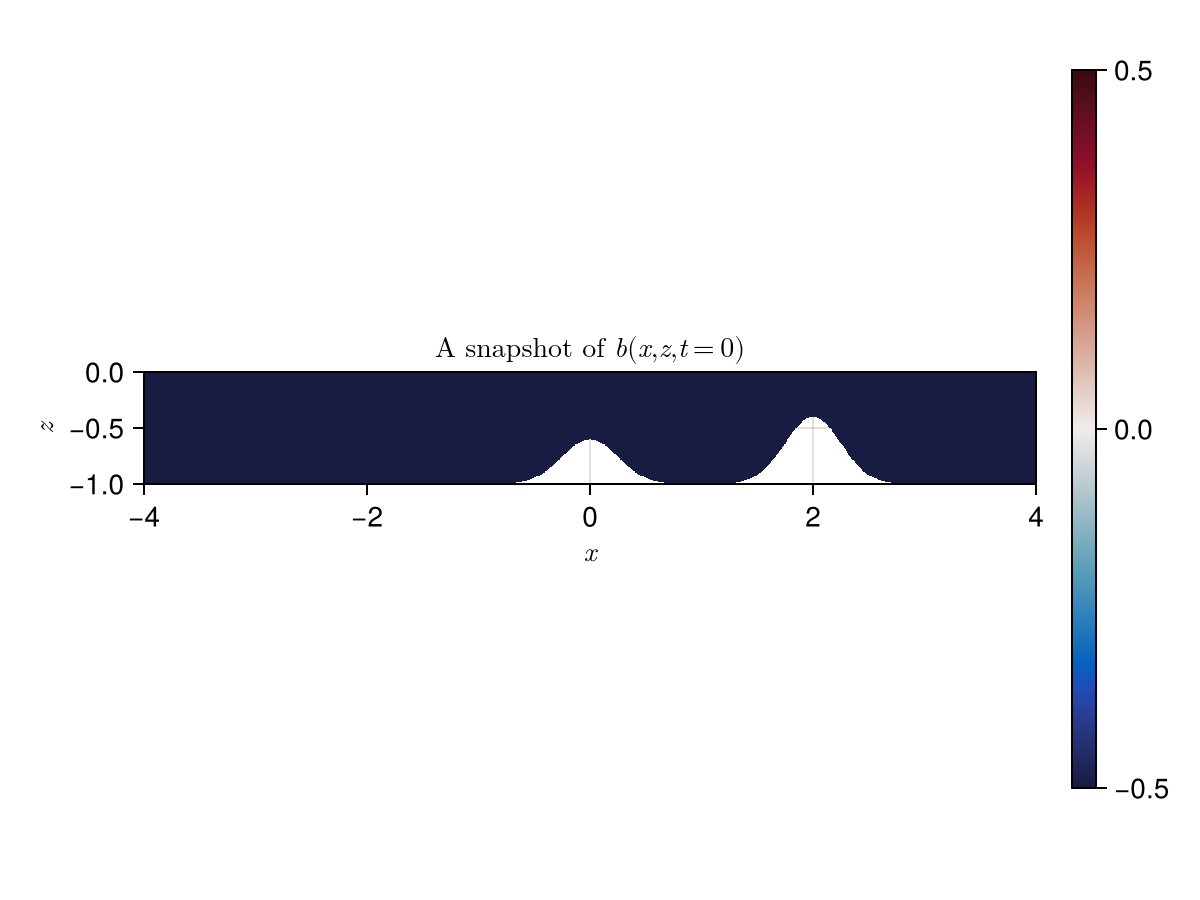

In [25]:
#okay lets plot a quick heatmap and see if that worked
#we should expect the buoyancy to be 0.5 everywhere and the hills to show up

f = Figure()
ax = Axis(f[1,1], aspect =8, xlabel = L"x", ylabel=L"z", title=L"\text{A snapshot of } b(x,z,t=0)")
hm = heatmap!(ax, x, z, b, colorrange=(-0.5, 0.5), colormap = :balance)
Colorbar(f[1,2], hm)
f

In [26]:
#okay z is already defined above, so now lets define z2d

z_3d = repeat(reshape(z, 1, 1, Nz), Nx, 1, 1);
b_flat = reshape(b, (Nx*Nz));
wet_flat = reshape(wet, (Nx*Nz));
z_flat = reshape(z_3d, (Nx*Nz));

In [27]:
#sort_idx is an array of indices that represents the sorted state of b_flat array
sort_idx = sortperm(b_flat);

#if we parse sort_idx through b_flat and z_flat then we get the SORTED b and z arrays

b_sorted, z_sorted = b_flat[sort_idx], z_flat[sort_idx];

In [28]:
#] add Interpolations

In [47]:
size(wet.*ΔA[:,1,:])

(951, 119)

In [38]:
#now we can reconstruct z* 
using Interpolations

ΔV_flat = ΔV[sort_idx];
size(ΔA)

A_wet = dropdims(sum(wet.*ΔA[:,1,:], dims=(1)), dims=(1));

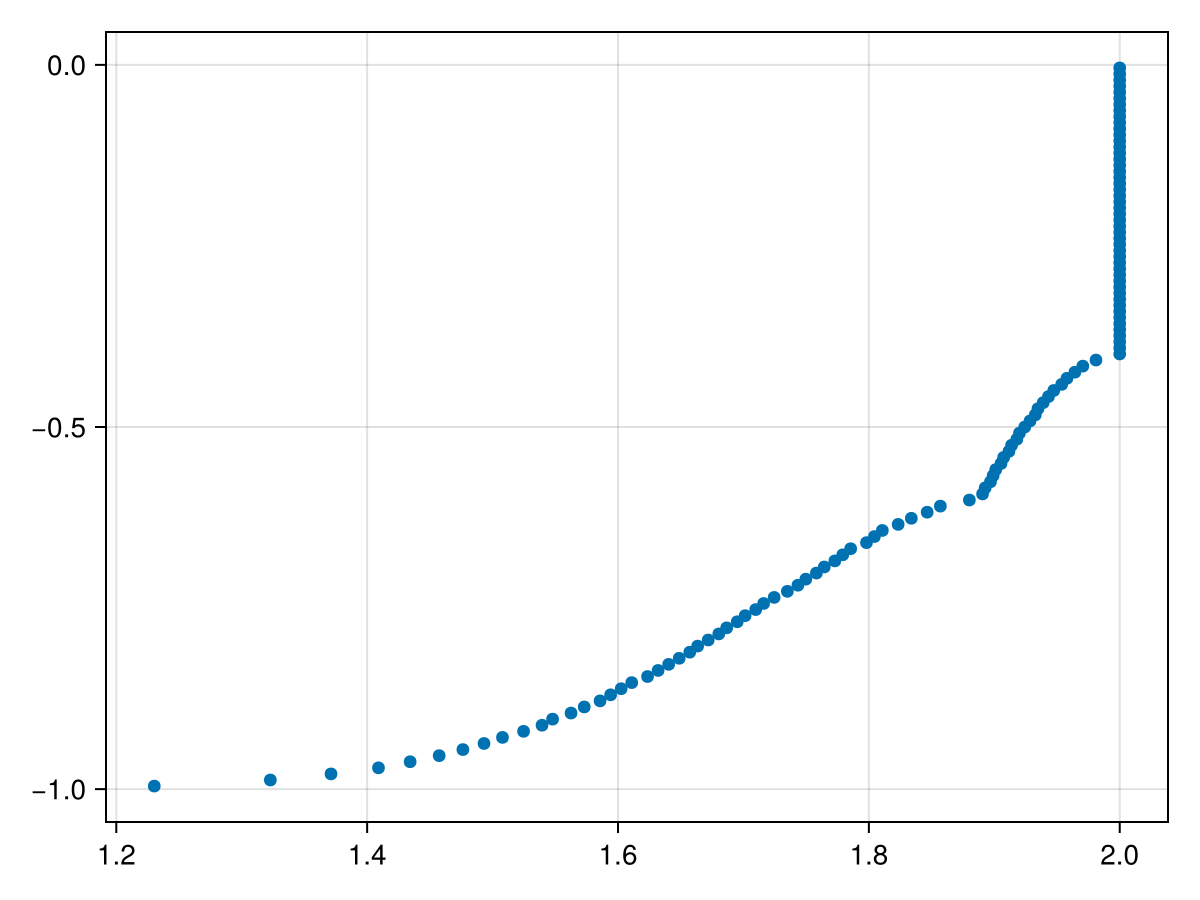

In [53]:
plot(A_wet, z)

In [54]:
A_interpolation = linear_interpolation(z, A_wet[:], extrapolation_bc=Line());

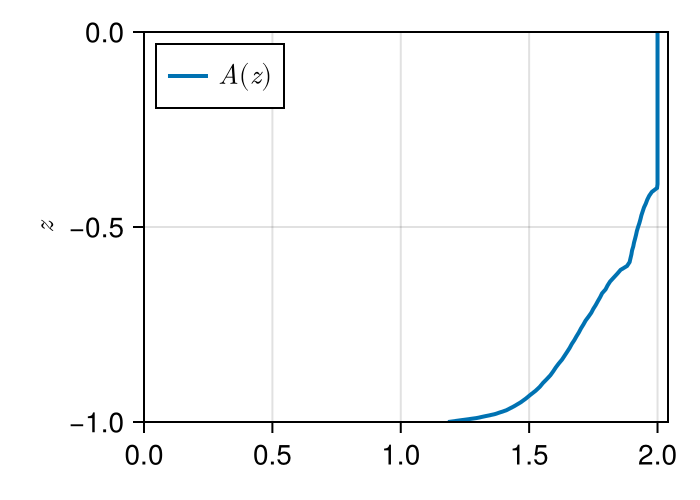

In [60]:
f_A = Figure(size=(350,250))
ax = Axis(f_A[1,1], ylabel=L"z", limits=((0, nothing), (-1,0)))
l = lines!(ax, A_interpolation(-1:0.01:0), collect(-1:0.01:0), linewidth=2, label=L"A(z)")
axislegend(ax, position=:lt)
f_A

In [61]:
z_bot = ds["zf"][5]
zstar_flat = zeros(size(b_sorted))
zstar_flat[1] = z_bot
for k in 2:length(b_sorted)
    A = A_interpolation(zstar_flat[k-1])
    if !isnan(b_sorted[k])
        zstar_flat[k] = zstar_flat[k-1] + ΔV_flat[k]/A
    else
        zstar_flat[k] = NaN
    end
end

LoadError: UndefVarError: `ds` not defined